# Backblaze Hard Drive RUL

**Project Goal:** Start from raw Backblaze quarterly ZIP files and build a clean training dataset for RUL/failure modeling.

**Notebook Purpose:** Run an end-to-end fresh pipeline that does not depend on previously extracted files.

**Workflow:**
1. Setup dependencies
2. Extract from raw ZIP files (streaming)
3. Identify top failing drive model(s)
4. Build raw extracted dataset for top model(s)
5. Clean and validate training dataset
6. Save cleaned dataset for model training
7. Perform EDA and baseline modeling

## Cell 1: Setup & Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from io import TextIOWrapper, BytesIO
from datetime import datetime
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("All dependencies imported successfully")

All dependencies imported successfully


## Cell 2A: Input Setup

In [2]:
def validate_zip_schema(zip_path, required_cols):
    """Validate that each CSV in ZIP contains required columns."""
    missing_by_csv = {}

    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        if not csv_files:
            return False, {'__zip__': ['No CSV files found in archive']}

        for file in csv_files:
            with z.open(file) as f:
                # Try multiple encodings to handle different CSV file encodings
                encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
                header_df = None
                for enc in encodings:
                    try:
                        f.seek(0)
                        header_df = pd.read_csv(TextIOWrapper(f, encoding=enc), nrows=0)
                        break
                    except (UnicodeDecodeError, AttributeError):
                        continue
                
                if header_df is None:
                    # Fallback: use UTF-8 with error replacement
                    f.seek(0)
                    header_df = pd.read_csv(TextIOWrapper(f, encoding='utf-8', errors='replace'), nrows=0)
                
                available = set(header_df.columns)
                missing = sorted(set(required_cols) - available)
                if missing:
                    missing_by_csv[file] = missing

    return len(missing_by_csv) == 0, missing_by_csv

## Cell 2B: Aggregate Failures and Extract Data for Top Failing Model(s)

In [3]:
def aggregate_failures_from_zip(zip_path):
    """First pass: aggregate failure counts by model from one ZIP."""
    model_failures = Counter()
    total_records = 0

    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]

        for file in csv_files:
            # Read file bytes once from ZIP
            file_bytes = z.read(file)
            
            # Try multiple encodings on the bytes
            encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
            df_chunk = None
            
            for enc in encodings:
                try:
                    df_chunk = pd.read_csv(
                        BytesIO(file_bytes),
                        usecols=agg_columns,
                        dtype=agg_dtypes,
                        chunksize=chunk_size,
                        encoding=enc
                    )
                    for chunk in df_chunk:
                        total_records += len(chunk)
                        failed = chunk[chunk['failure'] == 1]
                        if len(failed) > 0:
                            model_failures.update(failed['model'].value_counts().to_dict())
                    break
                except (UnicodeDecodeError, AttributeError, Exception):
                    continue
            
            # If all encodings failed, use latin-1 which accepts all bytes
            if df_chunk is None:
                try:
                    df_chunk = pd.read_csv(
                        BytesIO(file_bytes),
                        usecols=agg_columns,
                        dtype=agg_dtypes,
                        chunksize=chunk_size,
                        encoding='latin-1'
                    )
                    for chunk in df_chunk:
                        total_records += len(chunk)
                        failed = chunk[chunk['failure'] == 1]
                        if len(failed) > 0:
                            model_failures.update(failed['model'].value_counts().to_dict())
                except Exception as e:
                    print(f"Warning: Could not parse {file}: {e}")
                    continue

    return model_failures, total_records


def extract_top_models_from_zip(zip_path, target_models, quarter_label=None):
    """Second pass: extract selected columns for target models from one ZIP.
    
    Args:
        zip_path : Path to the ZIP file.
        target_models : List of model names to extract.
        quarter_label : Quarter label (e.g., 'Q1','Q2') to add as data_quarter column"""
    extracted_parts = []

    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]

        for file in csv_files:
            # Read file bytes once from ZIP
            file_bytes = z.read(file)
            
            # Try multiple encodings on the bytes
            encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
            df_part = None
            
            for enc in encodings:
                try:
                    df_part = pd.read_csv(
                        BytesIO(file_bytes),
                        usecols=lambda c: c in extract_columns,
                        dtype=extract_dtypes,
                        encoding=enc
                    )
                    break
                except (UnicodeDecodeError, AttributeError, Exception):
                    continue
            
            # If all encodings failed, use latin-1 which accepts all bytes
            if df_part is None:
                try:
                    df_part = pd.read_csv(
                        BytesIO(file_bytes),
                        usecols=lambda c: c in extract_columns,
                        dtype=extract_dtypes,
                        encoding='latin-1'
                    )
                except Exception as e:
                    print(f"Warning: Could not parse {file}: {e}")
                    continue

            if df_part is None or 'model' not in df_part.columns:
                continue

            filtered = df_part[df_part['model'].isin(target_models)]
            if len(filtered) > 0:
                # Add quarter label to trackwhich ZIP this data came from
                if quarter_label:
                    filtered['data_quarter'] = quarter_label
                extracted_parts.append(filtered)

    if extracted_parts:
        result_df = pd.concat(extracted_parts, ignore_index=True)
        # Ensure data_quarter column exists (for backward compatibility)
        if 'data_quarter' not in result_df.columns and quarter_label:
            result_df['data_quarter'] = quarter_label
        return result_df

    return pd.DataFrame(columns=extract_columns + (['data_quarter'] if quarter_label else []))

## Cell 2C: Initial EDA

ZIP files found for pre-EDA: 4

Scanning ZIP files (chunked)...
  data_Q1_2024.zip: 182 CSV files
  data_Q2_2024.zip: 182 CSV files
  data_Q3_2024.zip: 184 CSV files
  data_Q4_2024.zip: 184 CSV files

PRE-EXTRACTION EDA: FAILURE DISTRIBUTION OVER TIME
      date  records  failures  failure_rate_pct
2024-01-01   274660         3          0.001092
2024-01-02   274622         9          0.003277
2024-01-03   274649        15          0.005462
2024-01-04   274619        10          0.003641
2024-01-05   274653        17          0.006190
2024-01-06   274672         9          0.003277
2024-01-07   274674        11          0.004005
2024-01-08   274682        17          0.006189
2024-01-09   274694        16          0.005825
2024-01-10   274684        12          0.004369


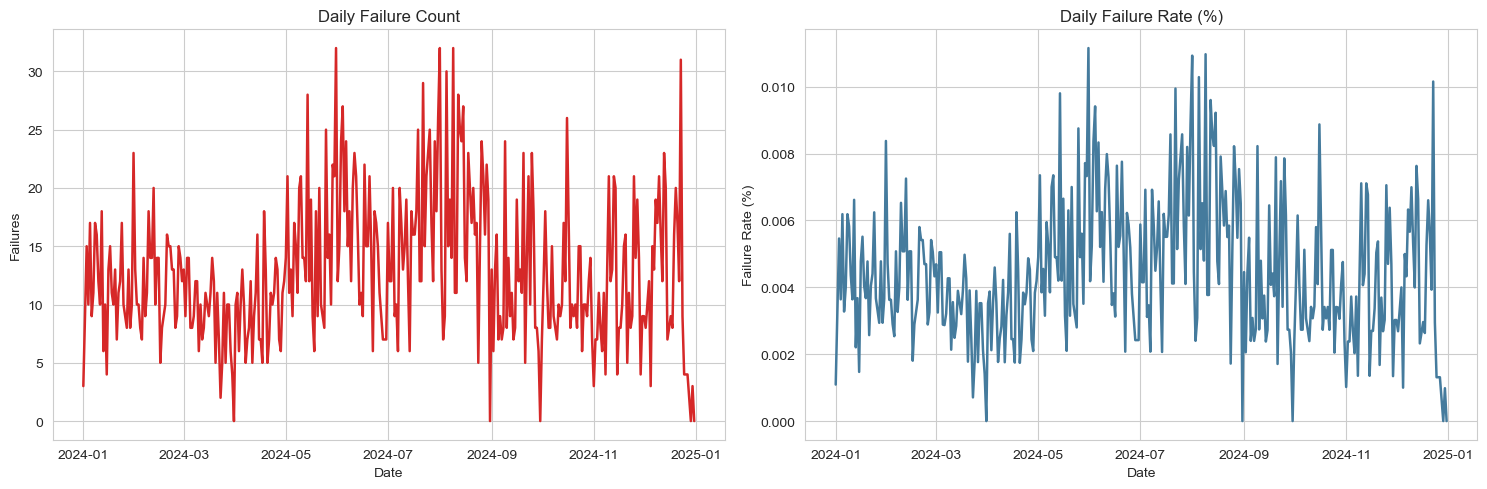


PRE-EXTRACTION EDA: FAILURE RATE BY MODEL

Top 15 models by failure count:
               model  records  failures  failure_rate_pct
HGST HUH721212ALN604  3816524       590          0.015459
       ST12000NM0008  7060183       502          0.007110
 TOSHIBA MG08ACA16TA 14089908       484          0.003435
HGST HUH721212ALE604  4826218       436          0.009034
 TOSHIBA MG07ACA14TA 13865254       415          0.002993
        ST8000NM0055  5021211       356          0.007090
       ST16000NM001G 11737654       226          0.001925
       ST14000NM001G  3902082       175          0.004485
       ST12000NM001G  4819992       166          0.003444
         ST8000DM002  3355907       162          0.004827
         ST4000DM000  1241520       141          0.011357
 WDC WUH722222ALE6L4  4741582       139          0.002932
       ST12000NM0007   400953       125          0.031176
 WDC WUH721816ALE6L4  9342943        88          0.000942
TOSHIBA MG08ACA16TEY  1892418        82          0.004

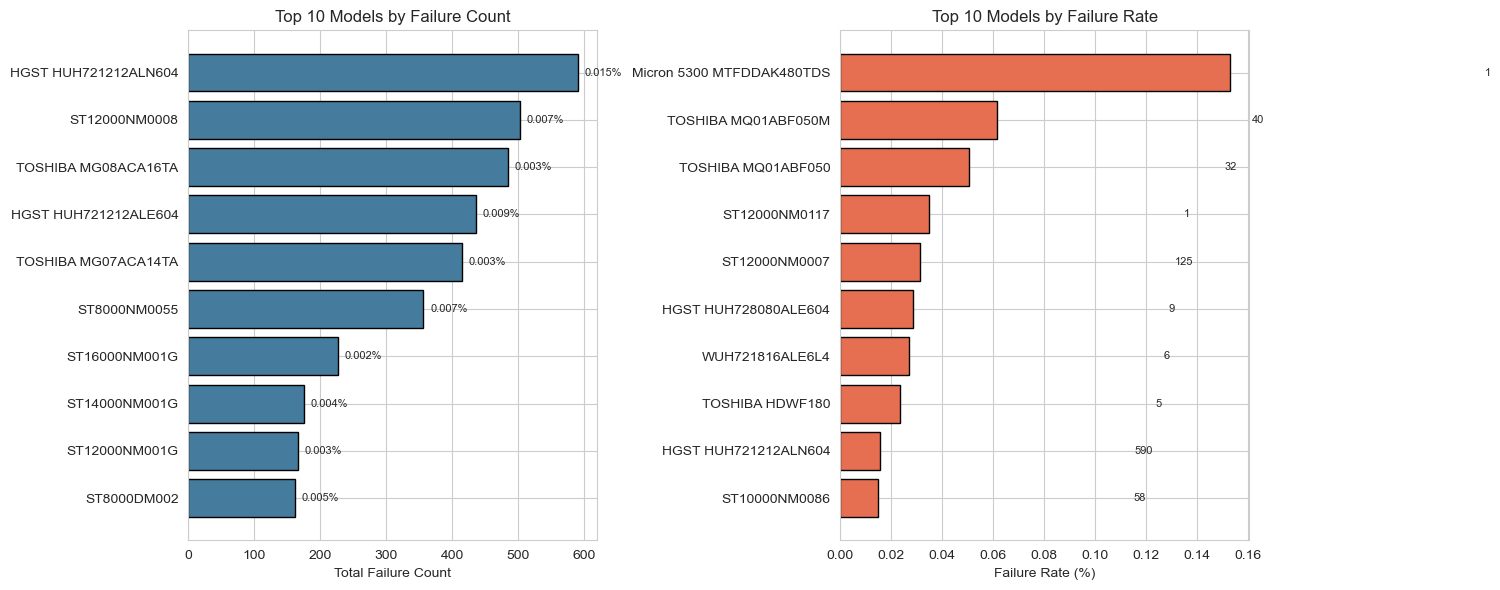

In [4]:
# Lightweight pre-extraction EDA: reads only date/model/failure in chunks
# This avoids loading all SMART columns and helps keep memory usage low.

pre_eda_zip_files = zip_files if 'zip_files' in locals() else [
    'data_Q1_2024.zip',
    'data_Q2_2024.zip',
    'data_Q3_2024.zip',
    'data_Q4_2024.zip'
]

available_pre_eda_zips = [p for p in pre_eda_zip_files if Path(p).exists()]
print(f"ZIP files found for pre-EDA: {len(available_pre_eda_zips)}")
if not available_pre_eda_zips:
    print("No ZIP files found in working directory. Skipping pre-extraction EDA.")
else:
    date_totals = Counter()
    date_failures = Counter()
    model_totals = Counter()
    model_failures = Counter()

    pre_eda_usecols = ['date', 'model', 'failure']
    pre_eda_dtype = {'date': str, 'model': str, 'failure': 'Int64'}
    pre_eda_chunk_size = 100000
    encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']

    print("\nScanning ZIP files (chunked)...")
    for zip_path in available_pre_eda_zips:
        with zipfile.ZipFile(zip_path, 'r') as z:
            csv_files = [f for f in z.namelist() if f.endswith('.csv')]
            print(f"  {zip_path}: {len(csv_files)} CSV files")

            for file in csv_files:
                parsed = False

                for enc in encodings:
                    try:
                        with z.open(file) as f:
                            reader = pd.read_csv(
                                TextIOWrapper(f, encoding=enc),
                                usecols=pre_eda_usecols,
                                dtype=pre_eda_dtype,
                                chunksize=pre_eda_chunk_size
                            )

                            for chunk in reader:
                                chunk = chunk.dropna(subset=['date', 'model', 'failure'])
                                if len(chunk) == 0:
                                    continue

                                chunk['date'] = pd.to_datetime(chunk['date'], errors='coerce')
                                chunk = chunk.dropna(subset=['date'])
                                if len(chunk) == 0:
                                    continue

                                chunk['date_key'] = chunk['date'].dt.date.astype(str)
                                chunk['failure'] = pd.to_numeric(chunk['failure'], errors='coerce').fillna(0).astype(int)

                                date_totals.update(chunk['date_key'].value_counts().to_dict())
                                date_failures.update(chunk.loc[chunk['failure'] == 1, 'date_key'].value_counts().to_dict())

                                model_totals.update(chunk['model'].value_counts().to_dict())
                                model_failures.update(chunk.loc[chunk['failure'] == 1, 'model'].value_counts().to_dict())

                        parsed = True
                        break
                    except Exception:
                        continue

                if not parsed:
                    print(f"    Warning: could not parse {file} with tested encodings")

    # Build daily failure trend
    if len(date_totals) > 0:
        daily_df = pd.DataFrame({
            'date': list(date_totals.keys()),
            'records': [date_totals[d] for d in date_totals.keys()],
            'failures': [date_failures.get(d, 0) for d in date_totals.keys()]
        })
        daily_df['date'] = pd.to_datetime(daily_df['date'], errors='coerce')
        daily_df = daily_df.dropna(subset=['date']).sort_values('date')
        daily_df['failure_rate_pct'] = (daily_df['failures'] / daily_df['records']) * 100

        print("\n" + "="*70)
        print("PRE-EXTRACTION EDA: FAILURE DISTRIBUTION OVER TIME")
        print("="*70)
        print(daily_df[['date', 'records', 'failures', 'failure_rate_pct']].head(10).to_string(index=False))

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        axes[0].plot(daily_df['date'], daily_df['failures'], color='#d62828', linewidth=1.8)
        axes[0].set_title('Daily Failure Count')
        axes[0].set_xlabel('Date')
        axes[0].set_ylabel('Failures')

        axes[1].plot(daily_df['date'], daily_df['failure_rate_pct'], color='#457b9d', linewidth=1.8)
        axes[1].set_title('Daily Failure Rate (%)')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Failure Rate (%)')

        plt.tight_layout()
        plt.show()

    # Build model failure-rate table
    if len(model_totals) > 0:
        model_summary = pd.DataFrame({
            'model': list(model_totals.keys()),
            'records': [model_totals[m] for m in model_totals.keys()],
            'failures': [model_failures.get(m, 0) for m in model_totals.keys()]
        })
        model_summary['failure_rate_pct'] = (model_summary['failures'] / model_summary['records']) * 100

        model_summary_filtered = model_summary.copy()

        print("\n" + "="*70)
        print("PRE-EXTRACTION EDA: FAILURE RATE BY MODEL")
        print("="*70)

        if len(model_summary_filtered) == 0:
            print("No models found.")
            model_summary_filtered = model_summary.copy()

        print("\nTop 15 models by failure count:")
        print(model_summary_filtered.sort_values('failures', ascending=False).head(15).to_string(index=False))

        # Create side-by-side charts: Failure Count vs Failure Rate
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Chart 1: Top 10 by Failure Count
        top10_count = model_summary_filtered.sort_values('failures', ascending=False).head(10)
        axes[0].barh(top10_count['model'], top10_count['failures'], color='#457b9d', edgecolor='black')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Total Failure Count')
        axes[0].set_title('Top 10 Models by Failure Count')
        # Add failure rate as annotation
        for i, (idx, row) in enumerate(top10_count.iterrows()):
            axes[0].text(row['failures'] + 10, i, f"{row['failure_rate_pct']:.3f}%", va='center', fontsize=8)

        # Chart 2: Top 10 by Failure Rate
        top10_rate = model_summary_filtered.sort_values('failure_rate_pct', ascending=False).head(10)
        axes[1].barh(top10_rate['model'], top10_rate['failure_rate_pct'], color='#e76f51', edgecolor='black')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Failure Rate (%)')
        axes[1].set_title('Top 10 Models by Failure Rate')
        # Add failure count as annotation
        for i, (idx, row) in enumerate(top10_rate.iterrows()):
            axes[1].text(row['failure_rate_pct'] + 0.1, i, f"{row['failures']:,}", va='center', fontsize=8)

        plt.tight_layout()
        plt.show()

## Cell 2D: Data Extraction Setup & Processing

In [5]:
# Define ZIP files to process
zip_files = [
    'data_Q1_2024.zip',
    'data_Q2_2024.zip',
    'data_Q3_2024.zip',
    'data_Q4_2024.zip'
]

# Verify files exist
print("Checking for ZIP files...")
available_zips = []
for zf in zip_files:
    if Path(zf).exists():
        available_zips.append(zf)
        print(f"  Found: {zf}")
    else:
        print(f"  Missing: {zf}")

if not available_zips:
    print("\nWarning: No ZIP files found in current directory!")
    print(f"Current directory: {Path.cwd()}")
    print("Please ensure data_Q*.zip files are in the working directory.")
else:
    print(f"\nProcessing {len(available_zips)} ZIP files...")

# Column configuration for aggregation (first pass: count failures by model)
agg_columns = ['model', 'failure']
agg_dtypes = {'model': str, 'failure': int}
chunk_size = 50000

# Column configuration for extraction (second pass: get selected SMART features for top models)
# Only extract essential columns to reduce memory usage
extract_columns = [
    'date',
    'serial_number',
    'model',
    'capacity_bytes',
    'failure',
    'smart_5_raw',
    'smart_187_raw',
    'smart_188_raw',
    'smart_197_raw',
    'smart_198_raw',
    'smart_189_raw',
    'smart_196_raw',
    'smart_9_raw'
]

extract_dtypes = {
    'date': str,
    'serial_number': str,
    'model': str,
    'capacity_bytes': float,
    'failure': int,
    'smart_5_raw': float,
    'smart_187_raw': float,
    'smart_188_raw': float,
    'smart_197_raw': float,
    'smart_198_raw': float,
    'smart_189_raw': float,
    'smart_196_raw': float,
    'smart_9_raw': float
}

# Step 1: Aggregate failures across all ZIP files
print("\n" + "="*70)
print("STEP 1: AGGREGATE FAILURES BY MODEL (all quarters)")
print("="*70)

all_model_failures = Counter()
total_records_all = 0

for zip_path in available_zips:
    if Path(zip_path).exists():
        model_failures, total_records = aggregate_failures_from_zip(zip_path)
        all_model_failures.update(model_failures)
        total_records_all += total_records
        print(f"\n{zip_path}: {total_records:,} records, {sum(model_failures.values()):,} failures")

print(f"\nTotal across all ZIPs: {total_records_all:,} records")
print(f"Total failures: {sum(all_model_failures.values()):,}")

# ------------------------------------------------------------
# Model selection for extraction
# ------------------------------------------------------------
# Option A: User-provided model(s) (recommended for targeted experiments)
# Example single model: user_selected_models = 'ST4000DM000'
# Example multiple models: user_selected_models = ['ST4000DM000', 'ST12000NM0007']
user_selected_models = None

# Option B fallback: use top failing model(s) when user_selected_models is None/empty
top_n_models = 1

target_models = []

if isinstance(user_selected_models, str):
    user_selected_models = [user_selected_models]

if user_selected_models:
    requested_models = [m.strip() for m in user_selected_models if isinstance(m, str) and m.strip()]
    available_model_set = set(all_model_failures.keys())

    matched_models = [m for m in requested_models if m in available_model_set]
    missing_models = [m for m in requested_models if m not in available_model_set]

    if matched_models:
        target_models = matched_models
        print("\nUsing user-selected model(s):")
        for rank, model in enumerate(target_models, 1):
            print(f"  {rank}. {model}")
        if missing_models:
            print(f"\nWarning: these requested models were not found in the aggregated data: {missing_models}")
    else:
        print("\nWarning: none of the user-selected models were found. Falling back to top failing model(s).")

if not target_models:
    top_models_list = all_model_failures.most_common(top_n_models)
    print(f"\nTop {top_n_models} failing model(s):")
    for rank, (model, count) in enumerate(top_models_list, 1):
        print(f"  {rank}. {model}: {count:,} failures")
    target_models = [model for model, count in top_models_list]

selected_model_count = len(target_models)

# Step 2: Extract data for selected models (with temporal tracking)
print("\n" + "="*70)
print(f"STEP 2: EXTRACT DATA FOR {selected_model_count} SELECTED MODEL(S) (selected SMART columns only)")
print("="*70)

# Mapping of ZIP files to quarters for temporal train-test split
zip_to_quarter = {
    'data_Q1_2024.zip': 'Q1',
    'data_Q2_2024.zip': 'Q2',
    'data_Q3_2024.zip': 'Q3',
    'data_Q4_2024.zip': 'Q4'
}

extracted_dfs = []
for zip_path in available_zips:
    if Path(zip_path).exists():
        quarter_label = zip_to_quarter.get(zip_path, 'Unknown')
        df_part = extract_top_models_from_zip(zip_path, target_models, quarter_label=quarter_label)
        if len(df_part) > 0:
            extracted_dfs.append(df_part)
            print(f"{zip_path}: ({quarter_label}): extracted {len(df_part):,} records for selected model(s)")
        else:
            print(f"{zip_path}: ({quarter_label}): no matching records")

# Combine all extracted data
if extracted_dfs:
    df = pd.concat(extracted_dfs, ignore_index=True)
    print(f"\nCombined dataset: {len(df):,} rows x {len(df.columns)} columns")
    print(f"Models: {df['model'].unique().tolist()}")
    print(f"Data quarters present: {df['data_quarter'].unique().tolist()}")
else:
    print("\nNo data extracted! Creating empty dataframe.")
    df = pd.DataFrame(columns=extract_columns + ['data_quarter'])

Checking for ZIP files...
  Found: data_Q1_2024.zip
  Found: data_Q2_2024.zip
  Found: data_Q3_2024.zip
  Found: data_Q4_2024.zip

Processing 4 ZIP files...

STEP 1: AGGREGATE FAILURES BY MODEL (all quarters)

data_Q1_2024.zip: 25,189,213 records, 978 failures

data_Q2_2024.zip: 26,022,269 records, 1,230 failures

data_Q3_2024.zip: 26,822,987 records, 1,424 failures

data_Q4_2024.zip: 27,345,292 records, 1,032 failures

Total across all ZIPs: 105,379,761 records
Total failures: 4,664

Top 1 failing model(s):
  1. HGST HUH721212ALN604: 590 failures

STEP 2: EXTRACT DATA FOR 1 SELECTED MODEL(S) (selected SMART columns only)
data_Q1_2024.zip: (Q1): extracted 958,729 records for selected model(s)
data_Q2_2024.zip: (Q2): extracted 957,573 records for selected model(s)
data_Q3_2024.zip: (Q3): extracted 956,688 records for selected model(s)
data_Q4_2024.zip: (Q4): extracted 943,534 records for selected model(s)

Combined dataset: 3,816,524 rows x 14 columns
Models: ['HGST HUH721212ALN604']
Da

In [6]:
print("="*70)
print("DATA QUALITY ASSESSMENT")
print("="*70)

# 1. Check for duplicates
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
print("\nDUPLICATES:")
print(f"   Total rows: {total_rows:,}")
print(f"   Duplicate rows: {duplicate_rows:,} ({duplicate_rows/total_rows*100:.3f}%)")

if duplicate_rows > 0:
    print("   Removing duplicates...")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"   Rows after dedup: {len(df):,}")

# 2. Missing data analysis
print("\nMISSING VALUES:")
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)
print(missing_df.to_string(index=False))

# 3. Data type coercions
print("\nDATA TYPE COERCIONS:")
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    print("   Converted 'date' to datetime64")

# Ensure numeric columns
smart_cols = [c for c in df.columns if c.endswith('_raw')]
numeric_cols = smart_cols + ['capacity_bytes']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
print(f"   Coerced {len(numeric_cols)} numeric columns")

# 4. Outlier detection
print("\nOUTLIER DETECTION (IQR method):")
outliers_count = 0
for col in numeric_cols:
    if col not in df.columns:
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_col = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_count += outliers_col
    if outliers_col > 0:
        print(f"   {col}: {outliers_col:,} outliers ({outliers_col/len(df)*100:.2f}%)")
print(f"   Total outliers detected: {outliers_count:,} (keeping for analysis)")

# 5. Data consistency checks
print("\nCONSISTENCY CHECKS:")
if 'failure' in df.columns:
    unique_failures = df['failure'].unique()
    print(f"   Failure column values: {sorted(unique_failures)}")
    if set(unique_failures).issubset({0, 1}):
        print("   Failure column is binary (valid)")
    else:
        print("   Warning: Unexpected failure values")

if 'capacity_bytes' in df.columns:
    print(f"   Capacity range: {df['capacity_bytes'].min():,.0f} to {df['capacity_bytes'].max():,.0f} bytes")

print("\nData quality assessment complete!")

DATA QUALITY ASSESSMENT

DUPLICATES:
   Total rows: 3,816,524
   Duplicate rows: 0 (0.000%)

MISSING VALUES:
        Column  Missing Count  Missing %
 smart_187_raw        3816524 100.000000
 smart_188_raw        3816524 100.000000
 smart_189_raw        3816524 100.000000
   smart_5_raw            191   0.005005
   smart_9_raw            191   0.005005
 smart_196_raw            191   0.005005
 smart_197_raw            191   0.005005
 smart_198_raw            191   0.005005
          date              0   0.000000
 serial_number              0   0.000000
         model              0   0.000000
capacity_bytes              0   0.000000
       failure              0   0.000000
  data_quarter              0   0.000000

DATA TYPE COERCIONS:
   Converted 'date' to datetime64
   Coerced 9 numeric columns

OUTLIER DETECTION (IQR method):
   smart_5_raw: 251,397 outliers (6.59%)
   smart_9_raw: 160,195 outliers (4.20%)
   smart_196_raw: 251,397 outliers (6.59%)
   smart_197_raw: 396,858 outlier

## Cell 3: Build and Save Fresh Cleaned Dataset for Model Training

In [7]:
# Create a model-training ready cleaned dataset from the fresh extraction
cleaned_training_df = df.copy()

# Drop columns that are too sparse (example threshold: >95% missing)
missing_pct = cleaned_training_df.isna().mean() * 100
high_missing_cols = missing_pct[missing_pct > 95].index.tolist()

# Keep identifier/date columns unless explicitly too sparse and non-essential
protected_cols = {'date', 'serial_number', 'model', 'failure'}
cols_to_drop = [c for c in high_missing_cols if c not in protected_cols]
if cols_to_drop:
    cleaned_training_df = cleaned_training_df.drop(columns=cols_to_drop)
    print(f"Dropped high-missing columns (>95%): {cols_to_drop}")
else:
    print('No high-missing feature columns dropped.')

# Ensure expected numeric typing before imputation
feature_cols = [c for c in cleaned_training_df.columns if c.endswith('_raw') or c == 'capacity_bytes']
for col in feature_cols:
    cleaned_training_df[col] = pd.to_numeric(cleaned_training_df[col], errors='coerce')

# Median imputation for model features
for col in feature_cols:
    median_val = cleaned_training_df[col].median()
    if pd.isna(median_val):
        median_val = 0.0
    cleaned_training_df[col] = cleaned_training_df[col].fillna(median_val)

# Final cleanup of key fields
if 'date' in cleaned_training_df.columns:
    cleaned_training_df['date'] = pd.to_datetime(cleaned_training_df['date'], errors='coerce')

cleaned_training_df = cleaned_training_df.drop_duplicates().reset_index(drop=True)

# Save fresh cleaned dataset
output_dir = Path('./rul_output')
output_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
cleaned_output_path = output_dir / f'fresh_start_cleaned_training_{timestamp}.csv'
cleaned_training_df.to_csv(cleaned_output_path, index=False)

print('\nFresh cleaned dataset created for model training:')
print(f'  Path: {cleaned_output_path}')
print(f'  Shape: {cleaned_training_df.shape[0]:,} rows x {cleaned_training_df.shape[1]} columns')
print(f'  Models: {cleaned_training_df["model"].nunique() if "model" in cleaned_training_df.columns else 0}')
print(f'  Failures: {(cleaned_training_df["failure"] == 1).sum() if "failure" in cleaned_training_df.columns else 0:,}')

cleaned_training_df.head()

Dropped high-missing columns (>95%): ['smart_187_raw', 'smart_188_raw', 'smart_189_raw']

Fresh cleaned dataset created for model training:
  Path: rul_output\fresh_start_cleaned_training_20260429_161101.csv
  Shape: 3,816,524 rows x 11 columns
  Models: 1
  Failures: 590


,date,serial_number,model,capacity_bytes,failure,smart_5_raw,smart_9_raw,smart_196_raw,smart_197_raw,smart_198_raw,data_quarter
0,2024-01-13,8DKHU24H,HGST HUH721212ALN604,1.200014e+13,0,0.0,35417.0,0.0,0.0,0.0,Q1
1,2024-01-13,5PG0P2VF,HGST HUH721212ALN604,1.200014e+13,0,0.0,32239.0,0.0,0.0,0.0,Q1
2,2024-01-13,AAG6E4KH,HGST HUH721212ALN604,1.200014e+13,0,0.0,43553.0,0.0,0.0,0.0,Q1
3,2024-01-13,8CHRG6JE,HGST HUH721212ALN604,1.200014e+13,0,0.0,36227.0,0.0,0.0,0.0,Q1
4,2024-01-13,8CHU2WSE,HGST HUH721212ALN604,1.200014e+13,0,0.0,31305.0,0.0,0.0,0.0,Q1


## Cell 4: Data Distributions

Data Distribution Analysis


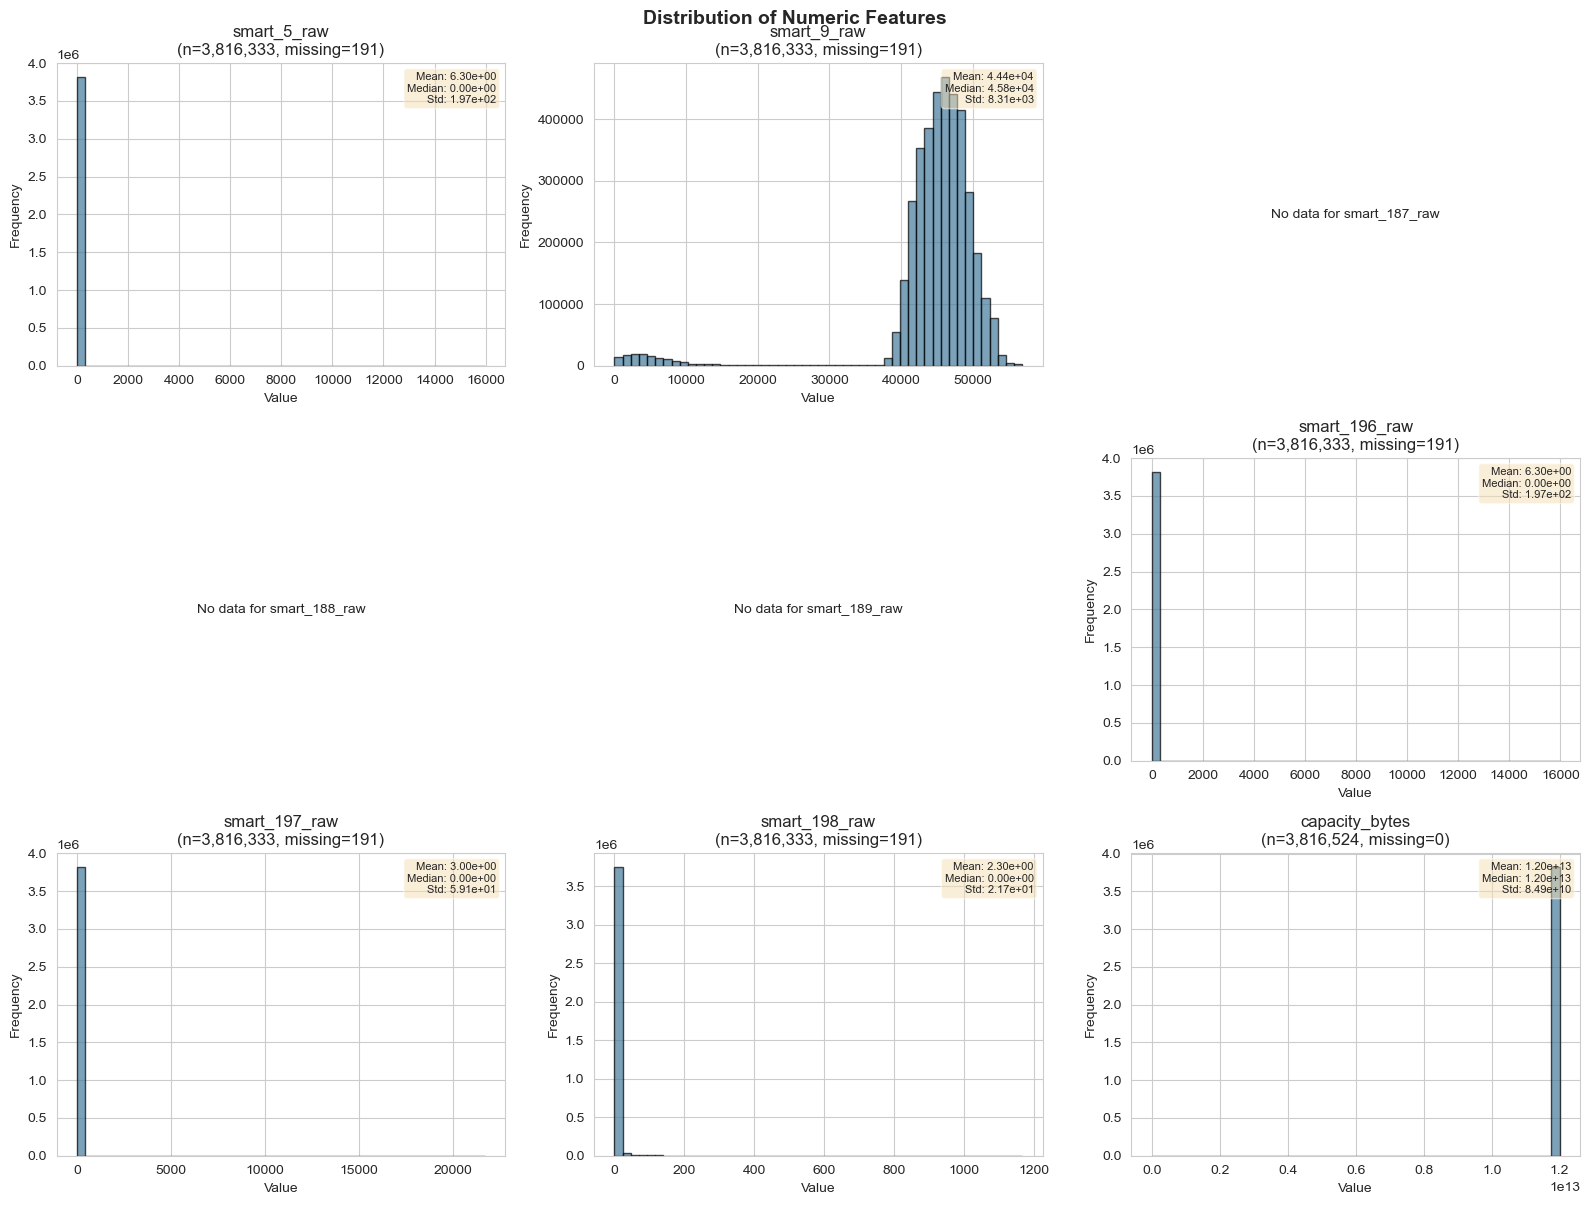


Descriptive Statistics:
        smart_5_raw   smart_9_raw  smart_187_raw  smart_188_raw  \
count  3.816333e+06  3.816333e+06            0.0            0.0   
mean   6.302300e+00  4.443681e+04            NaN            NaN   
std    1.972790e+02  8.305732e+03            NaN            NaN   
min    0.000000e+00  0.000000e+00            NaN            NaN   
25%    0.000000e+00  4.317200e+04            NaN            NaN   
50%    0.000000e+00  4.577000e+04            NaN            NaN   
75%    0.000000e+00  4.820600e+04            NaN            NaN   
max    1.597200e+04  5.693400e+04            NaN            NaN   

       smart_189_raw  smart_196_raw  smart_197_raw  smart_198_raw  \
count            0.0   3.816333e+06   3.816333e+06   3.816333e+06   
mean             NaN   6.302300e+00   2.997600e+00   2.299000e+00   
std              NaN   1.972790e+02   5.908110e+01   2.167780e+01   
min              NaN   0.000000e+00   0.000000e+00   0.000000e+00   
25%              NaN   0.0

In [8]:
print("="*70)
print("Data Distribution Analysis")
print("="*70)

# Identify feature columns
smart_cols = [c for c in df.columns if c.endswith('_raw')]
numeric_features = smart_cols + ['capacity_bytes']
numeric_features = [c for c in numeric_features if c in df.columns]

# Create distribution plots
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_features[:9]):
    ax = axes[idx]
    data_clean = df[col].dropna()
    
    if len(data_clean) == 0:
        ax.text(0.5, 0.5, f'No data for {col}', ha='center', va='center')
        ax.set_axis_off()
        continue
    
    ax.hist(data_clean, bins=50, color='#457b9d', alpha=0.7, edgecolor='black')
    ax.set_title(f'{col}\n(n={len(data_clean):,}, missing={df[col].isna().sum():,})')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    
    # Add statistics
    stats_text = f"Mean: {data_clean.mean():.2e}\nMedian: {data_clean.median():.2e}\nStd: {data_clean.std():.2e}"
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=8)

# Remove extra subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_axis_off()

plt.tight_layout()
plt.suptitle('Distribution of Numeric Features', y=1.00, fontsize=14, fontweight='bold')
plt.show()

# Print descriptive statistics
print("\nDescriptive Statistics:")
desc_stats = df[numeric_features].describe()
print(desc_stats.round(4))

## Cell 5: Class Balance & Target Analysis

CLASS BALANCE & TARGET VARIABLE ANALYSIS

CLASS DISTRIBUTION:
   Class 0 (No Failure):  3,815,934 drives (99.9845%)
   Class 1 (Failure):           590 drives (0.0155%)

   Imbalance Ratio: 6468:1 (heavily imbalanced)


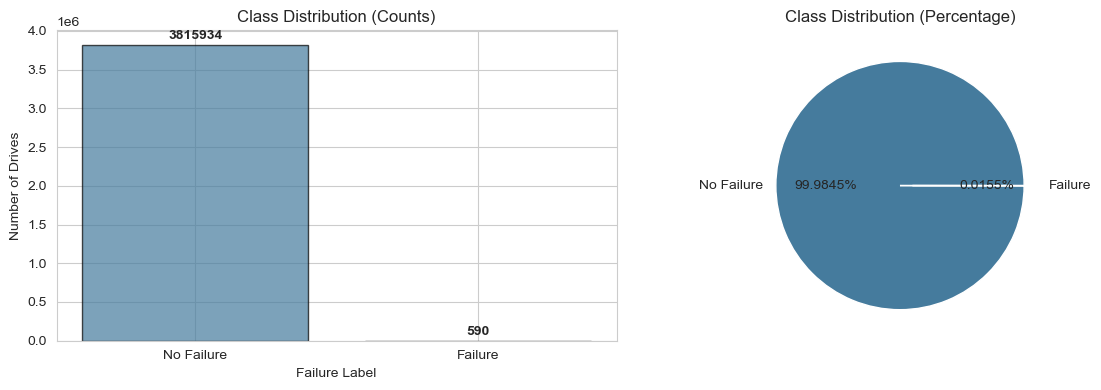

In [9]:
print("="*70)
print("CLASS BALANCE & TARGET VARIABLE ANALYSIS")
print("="*70)

if 'failure' in df.columns:
    # Class distribution
    class_counts = df['failure'].value_counts().sort_index()
    class_pcts = (class_counts / len(df)) * 100

    print("\nCLASS DISTRIBUTION:")
    print(f"   Class 0 (No Failure): {class_counts[0]:>10,} drives ({class_pcts[0]:>6.4f}%)")
    if 1 in class_counts.index:
        print(f"   Class 1 (Failure):    {class_counts[1]:>10,} drives ({class_pcts[1]:>6.4f}%)")
        imbalance_ratio = class_counts[0] / class_counts[1]
        print(f"\n   Imbalance Ratio: {imbalance_ratio:.0f}:1 (heavily imbalanced)")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar plot
    axes[0].bar(
        class_counts.index.astype(str),
        class_counts.values,
        color=['#457b9d', '#d62828'],
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Class Distribution (Counts)')
    axes[0].set_xlabel('Failure Label')
    axes[0].set_ylabel('Number of Drives')
    axes[0].set_xticklabels(['No Failure', 'Failure'])
    for i, v in enumerate(class_counts.values):
        axes[0].text(i, v + class_counts.max() * 0.02, str(v), ha='center', fontweight='bold')

    # Pie chart
    axes[1].pie(
        class_counts.values,
        labels=['No Failure', 'Failure'],
        autopct='%1.4f%%',
        colors=['#457b9d', '#d62828'],
        explode=(0, 0.1)
    )
    axes[1].set_title('Class Distribution (Percentage)')

    plt.tight_layout()
    plt.show()
else:
    print("No 'failure' column found for class balance analysis")

## Cell 6: Temporal Analysis

TEMPORAL ANALYSIS

Date Range: 2024-01-01 to 2024-12-31
   Total days covered: 365 days


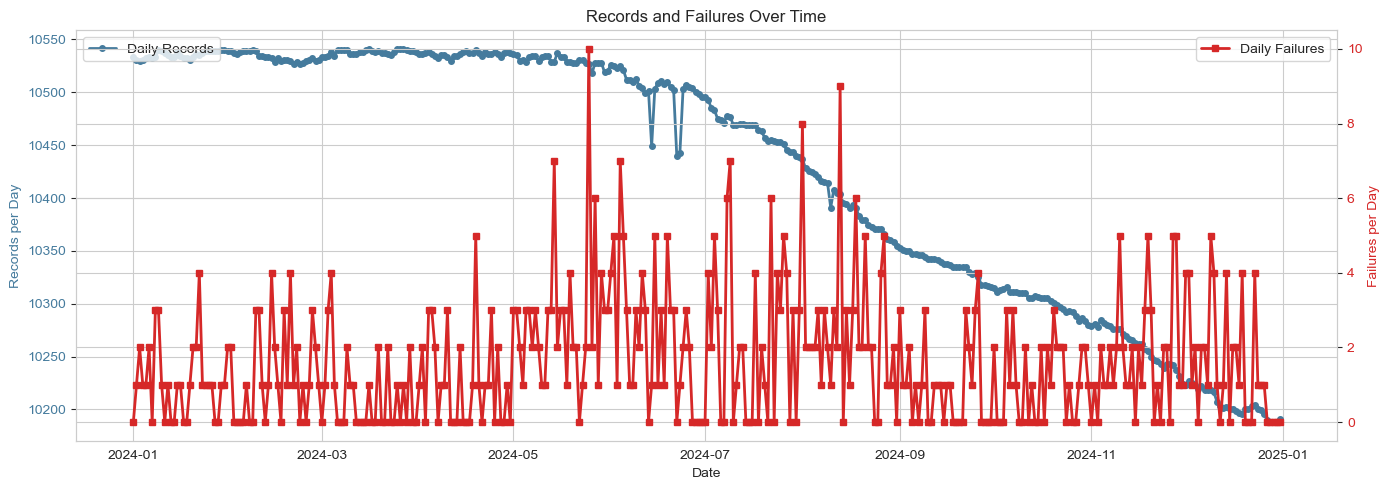

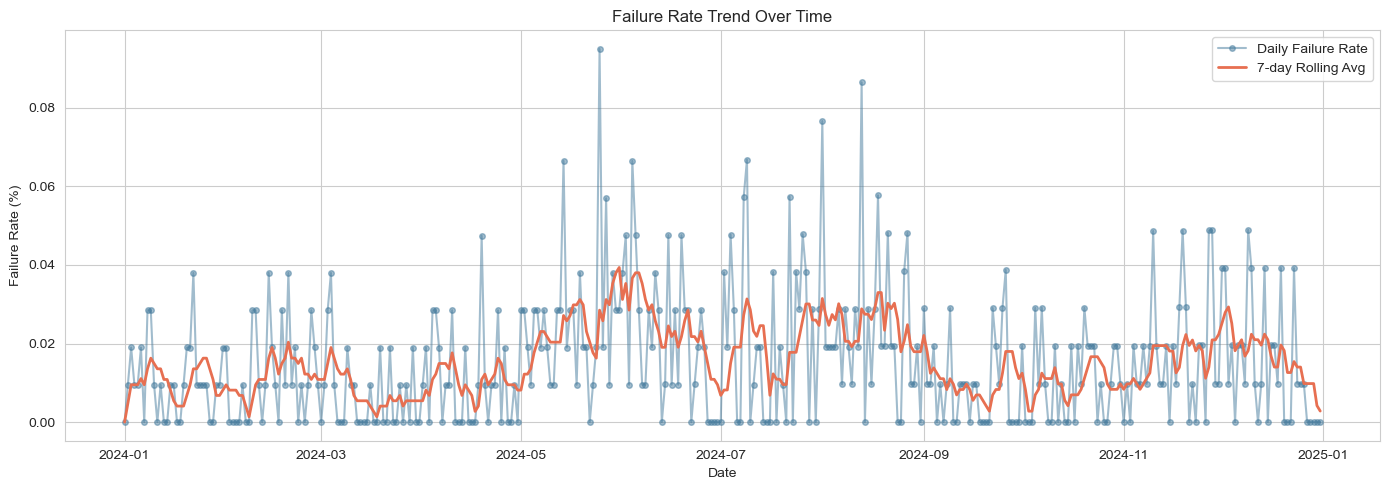


Quarterly Breakdown:
quarter  records  failures  failure_rate_pct
 2024Q1   958729        93          0.009700
 2024Q2   957573       188          0.019633
 2024Q3   956688       176          0.018397
 2024Q4   943534       133          0.014096


In [10]:
print("="*70)
print("TEMPORAL ANALYSIS")
print("="*70)

if 'date' in df.columns:
    # Parse dates
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df_temporal = df.dropna(subset=['date']).copy()
    
    print(f"\nDate Range: {df_temporal['date'].min().date()} to {df_temporal['date'].max().date()}")
    print(f"   Total days covered: {(df_temporal['date'].max() - df_temporal['date'].min()).days} days")
    
    # Daily statistics
    df_temporal['date_day'] = df_temporal['date'].dt.date
    daily_stats = df_temporal.groupby('date_day', as_index=False).agg(
        records=('failure', 'size'),
        failures=('failure', 'sum')
    )
    daily_stats['failure_rate_pct'] = (daily_stats['failures'] / daily_stats['records']) * 100
    
    # Convert grouped day column back to datetime for plotting
    daily_stats['date'] = pd.to_datetime(daily_stats['date_day'])
    daily_stats = daily_stats.sort_values('date').reset_index(drop=True)
    
    # Plot 1: Records and failures over time
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(daily_stats['date'], daily_stats['records'], marker='o', color='#457b9d', 
             label='Daily Records', linewidth=2, markersize=4)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Records per Day', color='#457b9d')
    ax1.tick_params(axis='y', labelcolor='#457b9d')
    
    ax2 = ax1.twinx()
    ax2.plot(daily_stats['date'], daily_stats['failures'], marker='s', color='#d62828', 
             label='Daily Failures', linewidth=2, markersize=4)
    ax2.set_ylabel('Failures per Day', color='#d62828')
    ax2.tick_params(axis='y', labelcolor='#d62828')
    
    plt.title('Records and Failures Over Time')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Failure rate over time with rolling average
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(daily_stats['date'], daily_stats['failure_rate_pct'], 
            marker='o', color='#457b9d', alpha=0.5, label='Daily Failure Rate', markersize=4)
    
    # Add 7-day rolling average
    rolling_avg = daily_stats['failure_rate_pct'].rolling(window=7, min_periods=1).mean()
    ax.plot(daily_stats['date'], rolling_avg, color='#e76f51', linewidth=2, label='7-day Rolling Avg')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Failure Rate (%)')
    ax.set_title('Failure Rate Trend Over Time')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Quarterly analysis
    print("\nQuarterly Breakdown:")
    df_temporal['quarter'] = df_temporal['date'].dt.to_period('Q')
    quarterly = df_temporal.groupby('quarter', as_index=False).agg(
        records=('failure', 'size'),
        failures=('failure', 'sum')
    )
    quarterly['failure_rate_pct'] = (quarterly['failures'] / quarterly['records']) * 100
    print(quarterly.to_string(index=False))
else:
    print("No 'date' column found for temporal analysis")

## Cell 7: Correlation Analysis

CORRELATION ANALYSIS


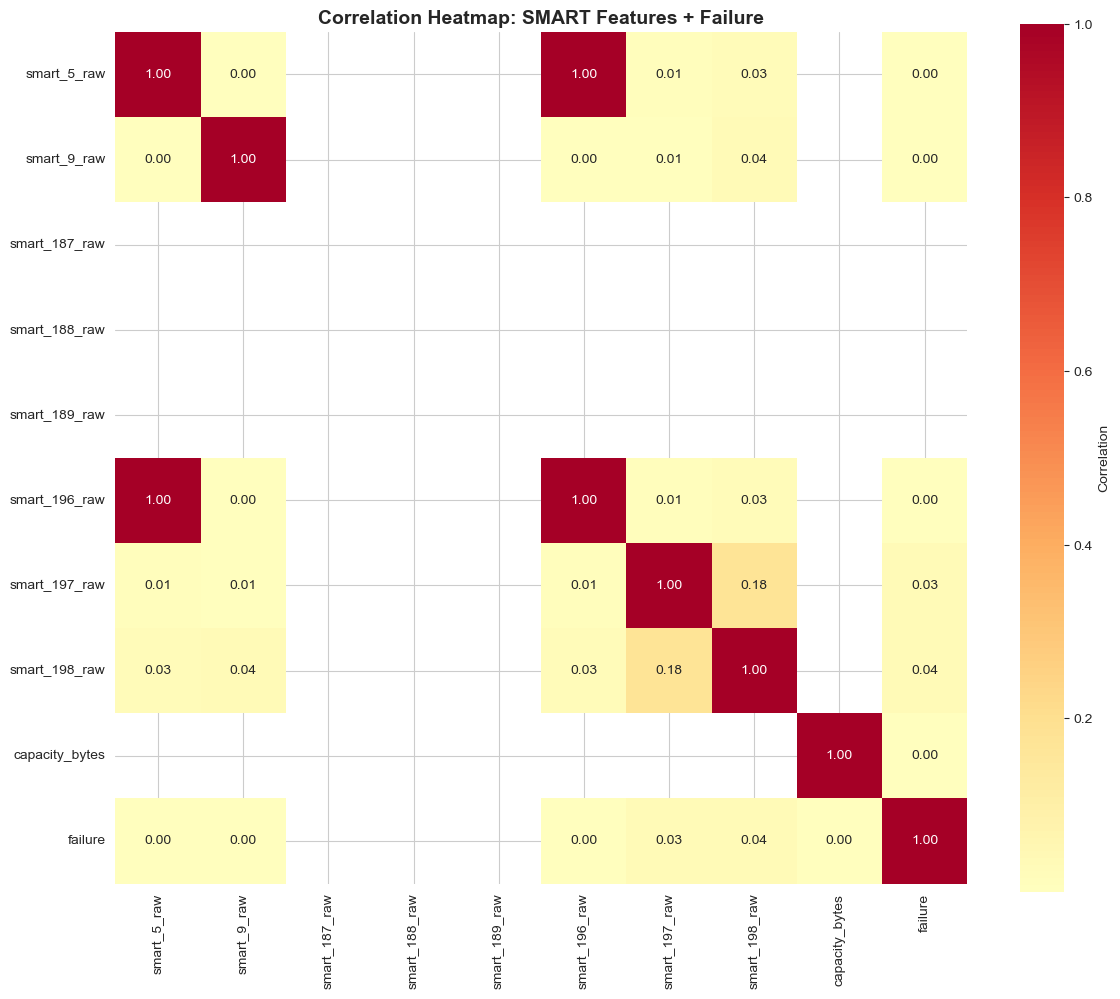


Feature Correlation with Failure (sorted by absolute value):
smart_198_raw     0.036395
smart_197_raw     0.034950
smart_5_raw       0.001996
smart_196_raw     0.001996
smart_9_raw       0.000776
capacity_bytes    0.000088
smart_187_raw          NaN
smart_188_raw          NaN
smart_189_raw          NaN

Highly Correlated Feature Pairs (|r| > 0.7):
   smart_5_raw          <-> smart_196_raw        :  1.0000


In [11]:
print("="*70)
print("CORRELATION ANALYSIS")
print("="*70)

smart_cols = [c for c in df.columns if c.endswith('_raw')]
numeric_features = smart_cols + ['capacity_bytes']
numeric_features = [c for c in numeric_features if c in df.columns]

# Add failure as target
corr_cols = numeric_features.copy()
if 'failure' in df.columns:
    corr_cols.append('failure')

# Correlation matrix
corr_data = df[corr_cols].copy()
for col in corr_cols:
    corr_data[col] = pd.to_numeric(corr_data[col], errors='coerce')

corr_matrix = corr_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, 
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap: SMART Features + Failure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature-Failure correlation
if 'failure' in df.columns:
    print("\nFeature Correlation with Failure (sorted by absolute value):")
    feature_failure_corr = corr_matrix['failure'].drop('failure').abs().sort_values(ascending=False)
    print(feature_failure_corr.to_string())
    
    # Identify highly correlated features (redundancy)
    print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))
    
    if high_corr_pairs:
        for feat1, feat2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f"   {feat1:20} <-> {feat2:20} : {corr_val:>7.4f}")
    else:
        print("   No highly correlated pairs found")

## Cell 8: Feature Engineering & Transformations

In [12]:
print("="*70)
print("FEATURE ENGINEERING & TRANSFORMATIONS")
print("="*70)

df_engineered = df.copy()

# 1. Log transformations for skewed features
print("\nLOG TRANSFORMATIONS (for skewed features):")
smart_cols = [c for c in df.columns if c.endswith('_raw')]

log_features_created = []
for col in smart_cols:
    if col in df_engineered.columns:
        # Check skewness
        data_clean = df_engineered[col].dropna()
        if len(data_clean) > 0 and (data_clean > 0).all():
            skewness = data_clean.skew()
            if abs(skewness) > 1:  # Moderately to highly skewed
                log_col = f"{col}_log"
                df_engineered[log_col] = np.log1p(df_engineered[col])
                log_features_created.append(log_col)
                print(f"   Created {log_col} (original skewness: {skewness:.2f})")

# 2. Polynomial features (select top features)
print("\nPOLYNOMIAL FEATURES (degree 2 for top features):")
from sklearn.preprocessing import PolynomialFeatures

# Get top correlated features with failure
if 'failure' in df.columns:
    corr_with_failure = corr_data.corr()['failure'].drop('failure').abs().sort_values(ascending=False).head(3)
    top_features = corr_with_failure.index.tolist()
    
    for feat in top_features:
        if feat in df_engineered.columns:
            poly_feat = f"{feat}_squared"
            df_engineered[poly_feat] = df_engineered[feat] ** 2
            print(f"   Created {poly_feat}")

# 3. Temporal features
print("\nTEMPORAL FEATURES:")
if 'date' in df_engineered.columns:
    df_engineered['date'] = pd.to_datetime(df_engineered['date'], errors='coerce')
    df_engineered['day_of_week'] = df_engineered['date'].dt.dayofweek
    df_engineered['month'] = df_engineered['date'].dt.month
    df_engineered['quarter'] = df_engineered['date'].dt.quarter
    df_engineered['day_of_year'] = df_engineered['date'].dt.dayofyear
    print("   Created day_of_week, month, quarter, day_of_year")

# 4. Interaction features
print("\nINTERACTION FEATURES:")
if 'capacity_bytes' in df_engineered.columns and len(smart_cols) > 0:
    cap_smart = f"{smart_cols[0]}_x_capacity"
    df_engineered[cap_smart] = df_engineered['capacity_bytes'] * df_engineered[smart_cols[0]]
    print(f"   Created {cap_smart}")

# 5. Categorical encodings (one-hot for model)
print("\nCATEGORICAL ENCODINGS:")
if 'model' in df_engineered.columns:
    model_dummies = pd.get_dummies(df_engineered['model'], prefix='model', drop_first=True)
    print(f"   Created {len(model_dummies.columns)} one-hot encoded model features")
    # Don't add to df for now, just show capability

print("\nFeature engineering complete!")
print(f"   Original features: {len(df.columns)}")
print(f"   Engineered features: {len(df_engineered.columns)}")
print(f"   New features created: {len(df_engineered.columns) - len(df.columns)}")

FEATURE ENGINEERING & TRANSFORMATIONS

LOG TRANSFORMATIONS (for skewed features):

POLYNOMIAL FEATURES (degree 2 for top features):
   Created smart_198_raw_squared
   Created smart_197_raw_squared
   Created smart_5_raw_squared

TEMPORAL FEATURES:
   Created day_of_week, month, quarter, day_of_year

INTERACTION FEATURES:
   Created smart_5_raw_x_capacity

CATEGORICAL ENCODINGS:
   Created 0 one-hot encoded model features

Feature engineering complete!
   Original features: 14
   Engineered features: 22
   New features created: 8


## Cell 9: Failure Relationships

Failure Relationships


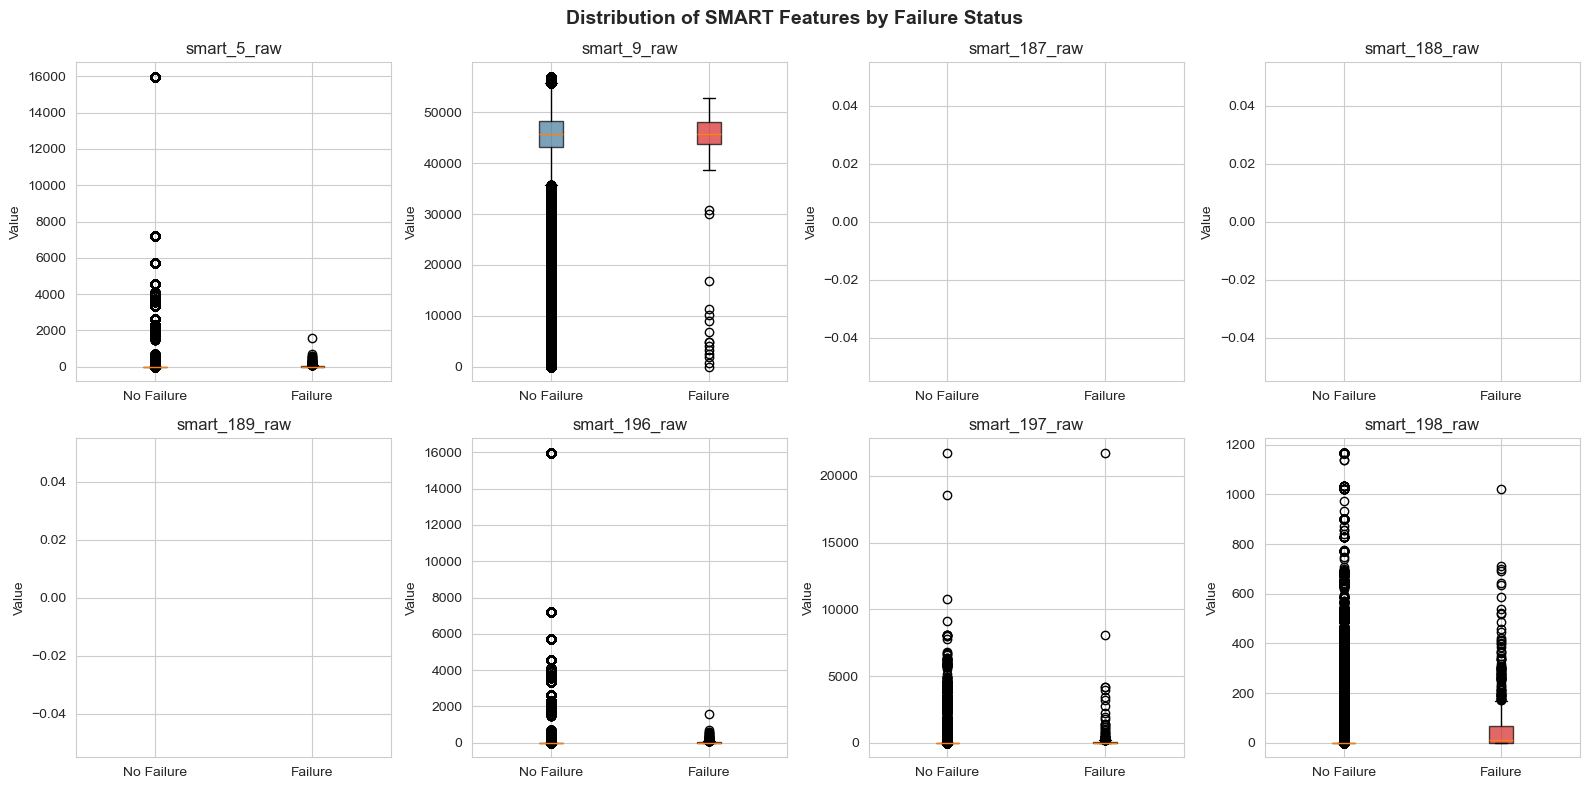


Feature Difference by Failure:
Feature                   Statistic       P-value         Significant    
----------------------------------------------------------------------
smart_5_raw               3.74e+08        0.000000        Yes (p<0.05)   
smart_9_raw               1.11e+09        0.680557        No             
smart_196_raw             3.74e+08        0.000000        Yes (p<0.05)   
smart_197_raw             2.03e+08        0.000000        Yes (p<0.05)   
smart_198_raw             3.77e+08        0.000000        Yes (p<0.05)   


In [13]:
print("="*70)
print("Failure Relationships")
print("="*70)

if 'failure' in df.columns:
    smart_cols = [c for c in df.columns if c.endswith('_raw')]
    
    # Box plots
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, col in enumerate(smart_cols[:8]):
        ax = axes[idx]
        
        data_to_plot = [df[df['failure'] == 0][col].dropna(),
                        df[df['failure'] == 1][col].dropna()]
        
        bp = ax.boxplot(data_to_plot, labels=['No Failure', 'Failure'],
                        patch_artist=True)
        
        # Color the boxes
        colors = ['#457b9d', '#d62828']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_title(col)
        ax.set_ylabel('Value')
    
    # Remove extra subplots
    for idx in range(len(smart_cols), len(axes)):
        axes[idx].set_axis_off()
    
    plt.suptitle('Distribution of SMART Features by Failure Status', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Statistical tests
    from scipy import stats
    print("\nFeature Difference by Failure:")
    print(f"{'Feature':<25} {'Statistic':<15} {'P-value':<15} {'Significant':<15}")
    print("-" * 70)
    
    for col in smart_cols[:8]:
        no_fail = df[df['failure'] == 0][col].dropna()
        fail = df[df['failure'] == 1][col].dropna()
        
        if len(no_fail) > 0 and len(fail) > 0:
            stat, pval = stats.mannwhitneyu(no_fail, fail)
            sig = "Yes (p<0.05)" if pval < 0.05 else "No"
            print(f"{col:<25} {stat:<15.2e} {pval:<15.6f} {sig:<15}")

## Cell 10: Baseline Model Development

In [14]:
print("="*70)
print("RUL BUCKET MODEL DEVELOPMENT & TRAINING")
print("="*70)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, confusion_matrix,
    classification_report, roc_curve
)

# Horizons (days to failure) to classify
rul_horizons = [2, 7, 14, 30]

# Prepare data
print("\n1) DATA PREPARATION:")
source_df = cleaned_training_df.copy() if 'cleaned_training_df' in locals() else df.copy()

# Ensure data_quarter column is preserved if it exists in original df
if 'data_quarter' in df.columns and 'data_quarter' not in source_df.columns:
    source_df['data_quarter'] = df['data_quarter']

required_cols = ['serial_number', 'date', 'failure']
missing_required = [c for c in required_cols if c not in source_df.columns]
if missing_required:
    print(f"Missing required columns for RUL bucketing: {missing_required}")
    print("Need serial_number, date, and failure to build days-to-failure labels.")
else:
    source_df['date'] = pd.to_datetime(source_df['date'], errors='coerce')
    source_df = source_df.dropna(subset=['serial_number', 'date']).copy()

    # Build days-to-failure by mapping each serial_number to its first observed failure date
    source_df = source_df.sort_values(['serial_number', 'date']).reset_index(drop=True)
    failure_dates = (
        source_df[source_df['failure'] == 1]
        .groupby('serial_number', as_index=True)['date']
        .min()
    )

    source_df['failure_date'] = source_df['serial_number'].map(failure_dates)
    source_df['days_to_failure'] = (source_df['failure_date'] - source_df['date']).dt.days

    # Remove rows after recorded failure event for failed drives
    source_df = source_df[(source_df['days_to_failure'].isna()) | (source_df['days_to_failure'] >= 0)].copy()

    # Create bucketed targets: fail within N days
    for horizon in rul_horizons:
        target_col = f'fail_within_{horizon}d'
        source_df[target_col] = (
            source_df['days_to_failure'].notna() & (source_df['days_to_failure'] <= horizon)
        ).astype(int)

    print(f"   Prepared rows for RUL labeling: {len(source_df):,}")
    print(f"   Drives with observed failures: {source_df['failure_date'].notna().sum():,}")

    # Select features
    feature_cols = [c for c in source_df.columns if c.endswith('_raw')] + ['capacity_bytes']
    feature_cols = [c for c in feature_cols if c in source_df.columns]

    X = source_df[feature_cols].copy()

    # Handle missing values once
    imputer = SimpleImputer(strategy='median', keep_empty_features=True)
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=feature_cols,
        index=X.index
    )

    print(f"   Features: {len(feature_cols)}")
    print(f"   Samples: {len(X_imputed):,}")

    # Temporal/Zip based train-test split: Q1-Q3 for training, Q4 for testing
    print(f"\n   Data split strategy: Temporal split by quarter (Q1-Q3 for training, Q4 for testing)")
    if 'data_quarter' in source_df.columns:
        train_mask = source_df['data_quarter'].isin(['Q1', 'Q2', 'Q3'])
        test_mask = source_df['data_quarter'] == 'Q4'

        X_train_full = X_imputed[train_mask].reset_index(drop=True)
        X_test_full = X_imputed[test_mask].reset_index(drop=True)

        print(f"   Training samples (Q1-Q3): {len(X_train_full):,}")
        print(f"   Testing samples (Q4): {len(X_test_full):,}")
    else:
        print("   Warning: 'data_quarter' column not found. Using random split instead.")
        train_mask = np.random.RandomState(seed=42).rand(len(X_imputed)) < 0.8
        test_mask = ~train_mask
        X_train_full = X_imputed[train_mask].reset_index(drop=True)
        X_test_full = X_imputed[test_mask].reset_index(drop=True)
        print(f"   Training samples: {len(X_train_full):,}")
        print(f"   Testing samples: {len(X_test_full):,}")

    horizon_models = {}
    horizon_test_data = {}
    horizon_metrics = []

    print("\n2) TRAIN & EVALUATE LOGISTIC REGRESSION FOR EACH RUL BUCKET:")
    for horizon in rul_horizons:
        target_col = f'fail_within_{horizon}d'
        y = source_df[target_col].copy()

        positives = int(y.sum())
        positive_rate = y.mean() * 100 if len(y) > 0 else 0
        print(f"\n   Horizon {horizon:>2}d -> positives: {positives:,} ({positive_rate:.4f}%)")

        if y.nunique() < 2:
            print("      Skipping: target has only one class.")
            horizon_metrics.append({
                'horizon_days': horizon,
                'samples': len(y),
                'positives': positives,
                'positive_rate_pct': positive_rate,
                'accuracy': np.nan,
                'roc_auc': np.nan,
                'f1_score': np.nan,
                'status': 'skipped_single_class'
            })
            continue
        
        # Use temporal split: Q1-Q3 for training, Q4 for testing
        y_train = y[train_mask].reset_index(drop=True)
        y_test = y[test_mask].reset_index(drop=True)
        X_train = X_train_full.copy()
        X_test = X_test_full.copy()

        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=feature_cols,
            index=X_train.index
        )
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=feature_cols,
            index=X_test.index
        )

        model = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba) if y_test.nunique() > 1 else np.nan
        f1 = f1_score(y_test, y_pred, zero_division=0)

        horizon_models[horizon] = model
        horizon_test_data[horizon] = {
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'feature_cols': feature_cols
        }

        horizon_metrics.append({
            'horizon_days': horizon,
            'samples': len(y),
            'positives': positives,
            'positive_rate_pct': positive_rate,
            'accuracy': acc,
            'roc_auc': auc,
            'f1_score': f1,
            'status': 'ok'
        })

        print(f"      Accuracy={acc:.4f} | ROC-AUC={auc:.4f} | F1={f1:.4f}")

    horizon_metrics_df = pd.DataFrame(horizon_metrics)

    # Backward compatibility for summary cell: use 30-day horizon as default
    summary_horizon = 30
    summary_row = horizon_metrics_df[horizon_metrics_df['horizon_days'] == summary_horizon]
    if not summary_row.empty and summary_row['status'].iloc[0] == 'ok':
        acc_baseline = float(summary_row['accuracy'].iloc[0])
        auc_baseline = float(summary_row['roc_auc'].iloc[0])
        f1_baseline = float(summary_row['f1_score'].iloc[0])
    else:
        acc_baseline = np.nan
        auc_baseline = np.nan
        f1_baseline = np.nan

    print("\nTraining complete for RUL buckets.")

RUL BUCKET MODEL DEVELOPMENT & TRAINING

1) DATA PREPARATION:
   Prepared rows for RUL labeling: 3,816,204
   Drives with observed failures: 111,054
   Features: 6
   Samples: 3,816,204

   Data split strategy: Temporal split by quarter (Q1-Q3 for training, Q4 for testing)
   Training samples (Q1-Q3): 2,872,846
   Testing samples (Q4): 943,358

2) TRAIN & EVALUATE LOGISTIC REGRESSION FOR EACH RUL BUCKET:

   Horizon  2d -> positives: 1,677 (0.0439%)
      Accuracy=0.9995 | ROC-AUC=0.8664 | F1=0.0000

   Horizon  7d -> positives: 4,377 (0.1147%)
      Accuracy=0.9989 | ROC-AUC=0.8576 | F1=0.0000

   Horizon 14d -> positives: 8,289 (0.2172%)
      Accuracy=0.9980 | ROC-AUC=0.8359 | F1=0.0011

   Horizon 30d -> positives: 17,248 (0.4520%)
      Accuracy=0.9957 | ROC-AUC=0.8104 | F1=0.0261

Training complete for RUL buckets.


## Cell 11: Baseline Model Evaluation

RUL BUCKET MODEL EVALUATION

PERFORMANCE SUMMARY BY HORIZON
----------------------------------------------------------------------
 horizon_days  samples  positives  positive_rate_pct  accuracy  roc_auc  f1_score status
            2  3816204       1677           0.043944  0.999511 0.866378  0.000000     ok
            7  3816204       4377           0.114695  0.998862 0.857649  0.000000     ok
           14  3816204       8289           0.217205  0.998004 0.835940  0.001061     ok
           30  3816204      17248           0.451967  0.995725 0.810404  0.026081     ok

HORIZON: FAIL WITHIN 2 DAYS
Confusion Matrix:
[[942897     98]
 [   363      0]]

Classification Report:
               precision    recall  f1-score   support

Not within 2d       1.00      1.00      1.00    942995
    Within 2d       0.00      0.00      0.00       363

     accuracy                           1.00    943358
    macro avg       0.50      0.50      0.50    943358
 weighted avg       1.00      1.00      1

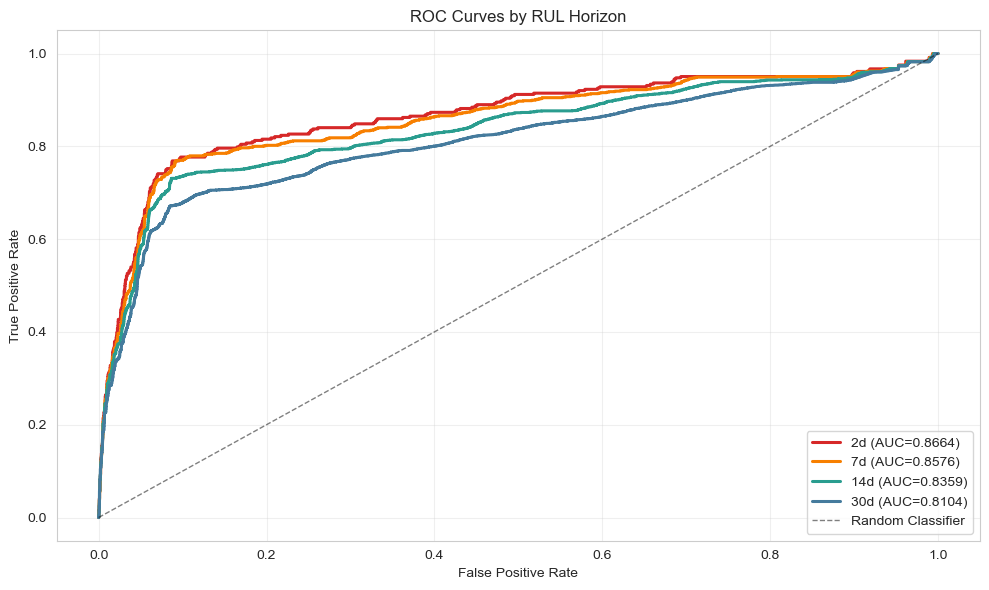


TOP 10 ABSOLUTE COEFFICIENTS (Logistic Regression, 30d horizon):
 1. smart_198_raw               0.185326
 2. smart_197_raw               0.096817
 3. smart_9_raw                 0.041879
 4. smart_196_raw               0.017052
 5. smart_5_raw                 0.017052
 6. capacity_bytes              0.004508


In [15]:
print("="*70)
print("RUL BUCKET MODEL EVALUATION")
print("="*70)

if 'horizon_metrics_df' not in locals() or horizon_metrics_df.empty:
    print("No RUL-bucket metrics found. Run Cell 10 first.")
else:
    print("\nPERFORMANCE SUMMARY BY HORIZON")
    print("-" * 70)
    display_cols = ['horizon_days', 'samples', 'positives', 'positive_rate_pct', 'accuracy', 'roc_auc', 'f1_score', 'status']
    print(horizon_metrics_df[display_cols].to_string(index=False))

    valid_horizons = [h for h in rul_horizons if h in horizon_test_data]

    if valid_horizons:
        # Detailed metrics for each horizon
        for horizon in valid_horizons:
            y_test = horizon_test_data[horizon]['y_test']
            y_pred = horizon_test_data[horizon]['y_pred']

            print("\n" + "=" * 70)
            print(f"HORIZON: FAIL WITHIN {horizon} DAYS")
            print("=" * 70)

            cm = confusion_matrix(y_test, y_pred)
            print("Confusion Matrix:")
            print(cm)

            print("\nClassification Report:")
            print(classification_report(
                y_test,
                y_pred,
                target_names=[f'Not within {horizon}d', f'Within {horizon}d'],
                zero_division=0
            ))

        # Combined ROC plot
        print("\nROC CURVES BY RUL HORIZON:")
        fig, ax = plt.subplots(figsize=(10, 6))

        colors = ['#d62828', '#f77f00', '#2a9d8f', '#457b9d']
        for i, horizon in enumerate(valid_horizons):
            y_test = horizon_test_data[horizon]['y_test']
            y_pred_proba = horizon_test_data[horizon]['y_pred_proba']

            if y_test.nunique() < 2:
                continue

            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc_val = horizon_metrics_df.loc[
                horizon_metrics_df['horizon_days'] == horizon, 'roc_auc'
            ].iloc[0]

            ax.plot(
                fpr,
                tpr,
                label=f'{horizon}d (AUC={auc_val:.4f})',
                linewidth=2.2,
                color=colors[i % len(colors)]
            )

        ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1, alpha=0.5)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('ROC Curves by RUL Horizon')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Coefficients from 30-day model (or first available horizon)
        coef_horizon = 30 if 30 in horizon_models else valid_horizons[0]
        coef_model = horizon_models[coef_horizon]
        coef_features = horizon_test_data[coef_horizon]['feature_cols']

        print(f"\nTOP 10 ABSOLUTE COEFFICIENTS (Logistic Regression, {coef_horizon}d horizon):")
        coef_abs = np.abs(coef_model.coef_[0])
        coef_idx = np.argsort(coef_abs)[::-1][:10]
        for rank, idx in enumerate(coef_idx, 1):
            print(f"{rank:2d}. {coef_features[idx]:<25} {coef_abs[idx]:>10.6f}")
    else:
        print("No valid horizons with trained models to evaluate.")

## Cell 13: Summary & Recommendations

In [16]:
print("="*70)
print("SUMMARY & RECOMMENDATIONS")
print("="*70)

if 'horizon_metrics_df' not in locals() or horizon_metrics_df.empty:
    print("RUL horizon metrics are not available yet. Run Cell 10 and Cell 11 first.")
else:
    metrics_view = horizon_metrics_df[['horizon_days', 'samples', 'positives', 'positive_rate_pct', 'accuracy', 'roc_auc', 'f1_score', 'status']].copy()

    print(f"""
SUMMARY

1. DATASET OVERVIEW
   - Total Records: {len(df):,}
   - Features: {len(df.columns)} columns (SMART metrics, capacity_bytes, metadata)
   - Time Period: {df['date'].min() if 'date' in df.columns else 'N/A'} to {df['date'].max() if 'date' in df.columns else 'N/A'}
   - Modeling Goal: Multi-horizon RUL bucket classification

2. RUL BUCKET DEFINITIONS
   - 2-day bucket: fail_within_2d
   - 7-day bucket: fail_within_7d
   - 14-day bucket: fail_within_14d
   - 30-day bucket: fail_within_30d

3. CLASS IMBALANCE CONTEXT
   - Positive labels become rarer at shorter horizons (for example, 2-day bucket)
   - This is expected in real operational datasets and impacts F1/recall more than accuracy

4. MODEL PERFORMANCE BY HORIZON
""")

    print(metrics_view.to_string(index=False))

    best_row = metrics_view[metrics_view['status'] == 'ok'].sort_values('roc_auc', ascending=False).head(1)
    if not best_row.empty:
        h = int(best_row['horizon_days'].iloc[0])
        auc = float(best_row['roc_auc'].iloc[0])
        f1 = float(best_row['f1_score'].iloc[0])
        print(f"\nBest ROC-AUC horizon: {h} days (AUC={auc:.4f}, F1={f1:.4f})")

    print("\n" + "="*70)
    print("ACTIONABLE RECOMMENDATIONS")
    print("="*70)

    recommendations = [
        ("HIGH PRIORITY", [
            "Use the 30-day horizon for broader early-warning screening",
            "Use shorter horizons (2d/7d) for urgent intervention workflows",
            "Track ROC-AUC, PR-AUC, and F1 per horizon due to severe imbalance",
            "Evaluate operating thresholds separately for each horizon"
        ]),
        ("MEDIUM PRIORITY", [
            "Apply class weighting or sampling per horizon to improve minority recall",
            "Validate temporal train-test split to avoid data leakage",
            "Calibrate probabilities before production alerting"
        ])
    ]

    for priority, items in recommendations:
        print(f"\n{priority}:")
        for i, item in enumerate(items, 1):
            print(f"   {i}. {item}")

    print("\n" + "="*70)
    print("RUL BUCKET MODELING COMPLETE")
    print("="*70)

SUMMARY & RECOMMENDATIONS

SUMMARY

1. DATASET OVERVIEW
   - Total Records: 3,816,524
   - Features: 14 columns (SMART metrics, capacity_bytes, metadata)
   - Time Period: 2024-01-01 00:00:00 to 2024-12-31 00:00:00
   - Modeling Goal: Multi-horizon RUL bucket classification

2. RUL BUCKET DEFINITIONS
   - 2-day bucket: fail_within_2d
   - 7-day bucket: fail_within_7d
   - 14-day bucket: fail_within_14d
   - 30-day bucket: fail_within_30d

3. CLASS IMBALANCE CONTEXT
   - Positive labels become rarer at shorter horizons (for example, 2-day bucket)
   - This is expected in real operational datasets and impacts F1/recall more than accuracy

4. MODEL PERFORMANCE BY HORIZON

 horizon_days  samples  positives  positive_rate_pct  accuracy  roc_auc  f1_score status
            2  3816204       1677           0.043944  0.999511 0.866378  0.000000     ok
            7  3816204       4377           0.114695  0.998862 0.857649  0.000000     ok
           14  3816204       8289           0.217205  0